In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### Load the dataset

In [2]:
df = pd.read_csv("bitcoin_data/raw/btc_3h.csv")

In [3]:
df

,datetime,open,high,low,close,volume
0,2020-01-01 00:00:00,7195.24,7244.87,7175.46,7242.85,2050.024313
1,2020-01-01 03:00:00,7242.66,7245.00,7215.03,7224.21,1596.208041
2,2020-01-01 06:00:00,7224.24,7236.27,7180.00,7200.64,2164.357851
3,2020-01-01 09:00:00,7200.29,7237.73,7185.20,7197.20,2251.108387
4,2020-01-01 12:00:00,7197.20,7234.97,7196.15,7221.43,2098.648667
...,...,...,...,...,...,...
18656,2026-05-21 09:00:00,77924.63,77977.53,77147.15,77189.10,1441.400320
18657,2026-05-21 12:00:00,77189.10,77363.32,76719.47,76984.61,1942.799910
18658,2026-05-21 15:00:00,76984.61,78098.16,76900.00,77869.38,2107.403020
18659,2026-05-21 18:00:00,77869.38,77922.01,77230.00,77705.81,1141.781970


In [4]:
df = df.sort_values('datetime')
df = df.set_index('datetime')

df['future_pct_move'] = (
    (df['close'].shift(-1) - df['close']) / df['close']
) * 100

df = df.dropna()

### Feature engineering

In [5]:
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['hl_range'] = (df['high'] - df['low']) / df['close']
df['oc_change'] = (df['close'] - df['open']) / df['open']

In [6]:
df = df.dropna()

### Split the data

In [7]:
train_end = "2026-05-21 00:00:00"
train = df[df.index <= train_end]
test = df[df.index > train_end]

In [8]:
df.isnull().sum()

open               0
high               0
low                0
close              0
volume             0
future_pct_move    0
log_return         0
hl_range           0
oc_change          0
dtype: int64

### Feature Scaling

In [9]:
feature_cols = ['open', 'high', 'low', 'close', 'log_return']


scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[feature_cols])
test_scaled = scaler.transform(test[feature_cols])

In [10]:
### Target feature
train_target = train['future_pct_move'].values
test_target = test['future_pct_move'].values

### Create Sequences

In [11]:
def create_sequences(features, target, lookback=60):
    X, y = [], []

    for i in range(lookback, len(features)):
        X.append(features[i-lookback:i])
        y.append(target[i])

    return np.array(X), np.array(y)

In [12]:
test_extended = np.vstack([
    train_scaled[-60:],   # lookback buffer
    test_scaled
])

test_target_extended = np.concatenate([
    train_target[-60:],
    test_target
])

In [13]:
X_train, y_train = create_sequences(train_scaled, train_target)
X_test, y_test = create_sequences(test_extended, test_target_extended)

### Build the dataset

### Train LSTM Model

In [14]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/Users/rajibul/Downloads/Data-Science-Projects/Financial_Market_Crypto/crypto/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(18593, 60, 5) (18593,)
(6, 60, 5) (6,)


### Train the Model

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 1.2268 - val_loss: 0.3975
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 1.2246 - val_loss: 0.3922
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.2242 - val_loss: 0.3918
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 1.2236 - val_loss: 0.3918
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 1.2241 - val_loss: 0.3937
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.2239 - val_loss: 0.3919
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 1.2238 - val_loss: 0.3926
Epoch 8/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.2235 - val_loss: 0.4056
Epoch 9/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.2239 - val_loss: 0.3921
Epoch 10/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.2235 - val_loss: 0.3924
Epoch 11/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 1.2235 - val_loss: 0.3923
Epoch 12/20
582/582 ━━━━━━━━━━━━━━━━━━━━

### Evaluate the Predictions

In [17]:
y_pred = model.predict(X_test).flatten()
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


array([0.0416793 , 0.04163191, 0.0416042 , 0.04152438, 0.04152478,
       0.04163414], dtype=float32)

In [18]:
test['future_pct_move_predictions'] = y_pred

In [19]:
data_all = pd.concat([test, train], sort=False)

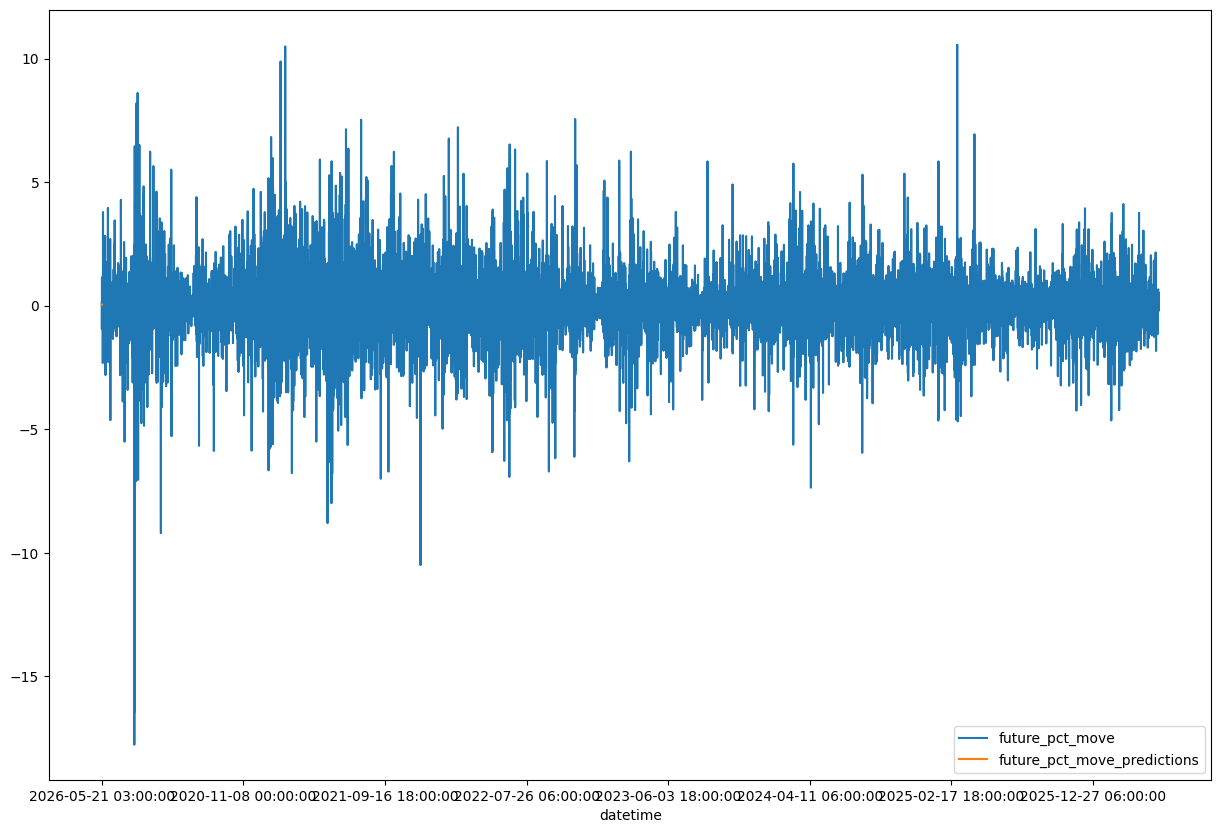

In [20]:
_ = data_all[['future_pct_move', 'future_pct_move_predictions']].plot(figsize=(15,10))

### Convert Predictions to trading signal

In [21]:
signals = np.where(
    y_pred > 0.5, 1,        # BUY
    np.where(y_pred < -0.5, -1, 0)  # SELL / HOLD
)

### Backtest strategy

In [22]:
strategy_returns = signals * y_test

In [23]:
strategy_returns

array([ 0., -0., -0.,  0., -0.,  0.])

### Performance Metrics

In [24]:
print("Total Return:", np.sum(strategy_returns))

Total Return: 0.0


### Sharpe Ratio

In [25]:
sharpe = np.mean(strategy_returns) / np.std(strategy_returns)
print("Sharpe:", sharpe)

Sharpe: nan


/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_16975/2604842701.py:1: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = np.mean(strategy_returns) / np.std(strategy_returns)


### Plot equity curve

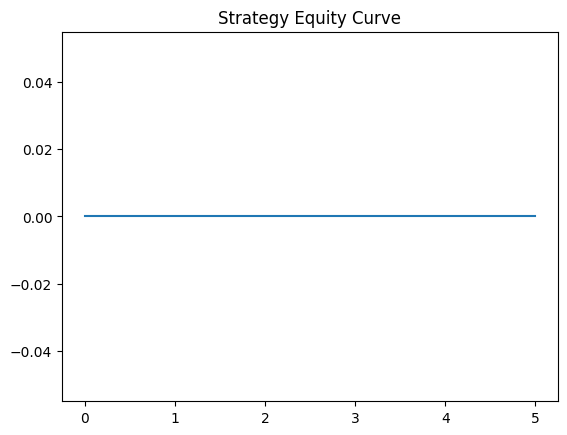

In [26]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(strategy_returns))
plt.title("Strategy Equity Curve")
plt.show()